Profesor: Fernando Carazo - fernando.carazo@veeva.com



# Autoencoders para la detección de anomalías cardiacas
## 1- El problema a resolver

Detectar la presencia (sujeto *anormal*) o ausencia (sujeto *normal*) de irregularidades en el ritmo cardiaco, a partir de señales electrocardiográficas (ECG):

![](https://drive.google.com/uc?export=view&id=1pzydaNRbcSh1E-S4Ebh0jJEqsim6DeM9)

El problema es que usualmente se cuenta con sets de datos **desbalanceados** con más datos normales que anormales.
## 2- El set de datos

Se usará el set [ECG5000](https://timeseriesclassification.com/description.php?Dataset=ECG5000) con 7600 datos de entrenamiento y 1900 de prueba.

Cada dato contiene un ciclo cardiaco con 140 muestras, y que puede pertenecer a una de 5 categorías:

1. Normal
2. Anormal: contracción ventricular prematura
3. Anormal: contracción supra-ventricular prematura
4. Anormal: latido ectópico
5. Anormal pero patología desconocida

![](https://drive.google.com/uc?export=view&id=1x_sUD1rbM4MM4--s9D4wacRIWEo8aAzL)

## 3- Autoencoders y detección de anomalías

El problema del set ECG5000 es que contiene 4427 datos normales y 3173 anormales, es decir está desbalanceado.

De hecho para ciertas categorías anormales (2 a 4) se tienen muy pocos datos:

| Categoría   | Nro. datos |
|-------------|------------|
| 1 (normal)  | 4427       |
| 2 (anormal) | 2683       |
| 3 (anormal) | 149        |
| 4 (anormal) | 306        |
| 5 (anormal) | 35         |

Así que en lugar de un modelo de clasificación convencional (como una Red Neuronal) se usará un Autoencoder:

![](https://drive.google.com/uc?export=view&id=1LnoIDmfctQr5wmJaojFrZEA1ygPynylu)

El autoencoder se entrenará **únicamente con datos normales**. Así, al reconstruir un dato anormal **el error será alto**.

In [ ]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [ ]:
ruta = ''

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df_train = pd.read_csv(ruta + 'ECG5000_train.csv')
df_test = pd.read_csv(ruta + 'ECG5000_test.csv')

df_train["0"] = df_train["0"] - 1
df_test["0"] = df_test["0"] - 1
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,0,-1.30300,-0.83573,-1.9336,-2.09420,-2.02840,-1.2531,-0.52638,-0.089286,-0.07557,...,-1.45820,-1.6676,-1.5977,-1.67930,-1.677200,-1.69370,-1.79410,-1.35940,-2.08120,-2.82880
1,1,0.32288,-0.87847,-1.8023,-2.66850,-3.26550,-3.3326,-2.88000,-2.227400,-1.54360,...,-1.23050,-1.7218,-2.1953,-2.74890,-3.446500,-3.66210,-3.01820,-1.65140,-0.23670,0.82832
2,1,1.39340,1.59260,1.2420,0.79449,0.19577,-0.3156,-0.58053,-0.945020,-1.23350,...,-1.90850,-2.5295,-3.0614,-3.50370,-3.900400,-4.24600,-4.13380,-3.19850,-2.42200,-1.07370
3,0,-3.52270,-5.02610,-4.3613,-4.10570,-3.10420,-1.8178,-1.39840,-1.070100,-0.40691,...,0.83038,1.0084,1.1830,0.94636,0.952130,0.79343,0.84741,1.01390,0.31234,-2.19060
4,0,-1.91820,-3.22510,-3.4652,-4.00800,-3.87030,-3.3581,-2.28540,-1.728500,-1.42220,...,1.77690,1.5029,1.1651,0.46073,0.019172,-0.32739,-0.48051,-0.18814,0.14284,-0.66844


In [ ]:
df_train['0'].value_counts()

,count
0,
0,4427
1,2683
3,306
2,149
4,35


In [ ]:
df_train["0"].value_counts()

y_train = df_train["0"]
x_train = df_train.drop(columns=["0"])
y_test = df_test["0"]
x_test = df_test.drop(columns=["0"])

import keras
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping, ModelCheckpoint


model = Sequential()
model.add(Input(shape=(140,)))
model.add(Dense(64, activation="relu"))
model.add(Dense(5, activation="softmax"))

model.summary()



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         9,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,349 (36.52 KB)

 Trainable params: 9,349 (36.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer = keras.optimizers.SGD(), loss=keras.losses.sparse_categorical_crossentropy)
history = model.fit(x=x_train, y=y_train, epochs=40, validation_data=(x_test, y_test))

Epoch 1/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4760 - val_loss: 0.2272
Epoch 2/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2421 - val_loss: 0.2009
Epoch 3/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2260 - val_loss: 0.1886
Epoch 4/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2018 - val_loss: 0.1819
Epoch 5/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1954 - val_loss: 0.1745
Epoch 6/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1816 - val_loss: 0.1699
Epoch 7/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1907 - val_loss: 0.1648
Epoch 8/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1890 - val_loss: 0.1611
Epoch 9/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1745 - val_loss: 0.1601
Epoch 10/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1616 - val_loss: 0.1560
Epoch 11/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1639 - val_loss: 0.1531
Epoch 12/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

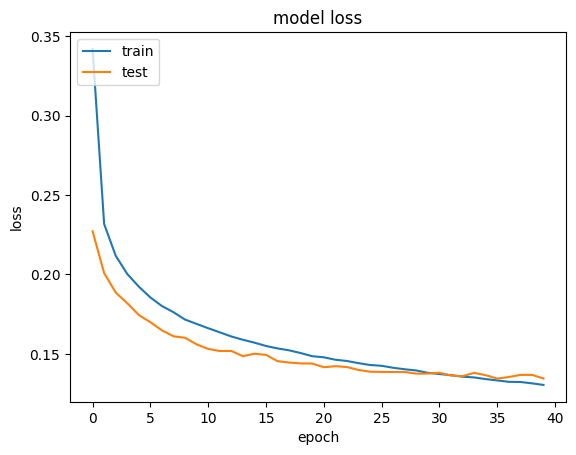

In [ ]:
# plot history
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
predictions_p = model.predict(x_test)
predictions = predictions_p.argmax(axis=1)

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


0.9642105263157895
Accuracy clase 0: 0.9973
Accuracy clase 1: 0.9822
Accuracy clase 2: 0.6970
Accuracy clase 3: 0.4444
Accuracy clase 4: 0.2727


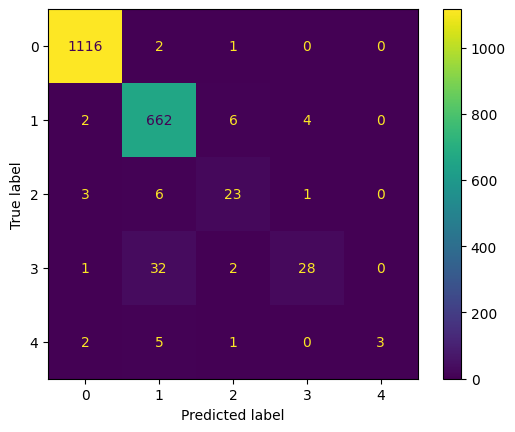

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cf = confusion_matrix(y_test, predictions)
conf = ConfusionMatrixDisplay(cf)

conf.plot()
print(np.mean(y_test == predictions))

accuracy_per_class = np.diag(cf) / np.sum(cf, axis=1)

# Imprimir resultados
for i, acc in enumerate(accuracy_per_class):
    print(f'Accuracy clase {i}: {acc:.4f}')

In [ ]:

callbacks_model = [
    EarlyStopping(monitor="val_loss", patience=5, verbose=1),
    ModelCheckpoint(filepath="model.keras", save_best_only=True, verbose=1)
]

model = Sequential()
model.add(Input(shape=(140,)))
model.add(Dense(32, activation="relu"))
model.add(Dense(5, activation="softmax"))

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

history = model.fit(
    x_train,
    y_train,
    epochs=300,
    batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=callbacks_model
)
# model.compile(loss=keras.losses.SparseCategoricalCrossentropy())

# model.summary()

predictions = model.predict(x_train)
predictions_label = np.argmax(predictions, axis=1)

predictions_label[:2]

accuracy = np.mean(predictions_label == y_train)
print(accuracy)

Epoch 1/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8697 - loss: 0.4093
Epoch 1: val_loss improved from inf to 0.18245, saving model to model.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8699 - loss: 0.4088 - val_accuracy: 0.9489 - val_loss: 0.1825
Epoch 2/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9458 - loss: 0.1898
Epoch 2: val_loss improved from 0.18245 to 0.15788, saving model to model.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9458 - loss: 0.1897 - val_accuracy: 0.9542 - val_loss: 0.1579
Epoch 3/300
217/238 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9565 - loss: 0.1554
Epoch 3: val_loss improved from 0.15788 to 0.14980, saving model to model.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9563 - loss: 0.1560 - val_accuracy: 0.9574 - val_loss: 0.1498
Epoch 4/300
227/238 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9561 - loss: 0.1496
Epoch 4: val_loss improved from 0.14980 to 0.14294, saving model

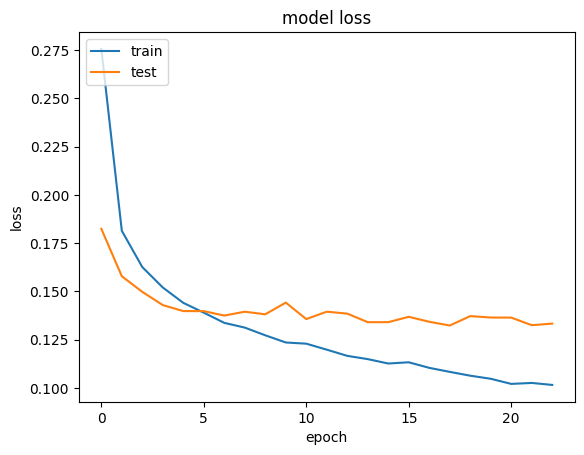

In [ ]:
# plot history
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# Autoencoders

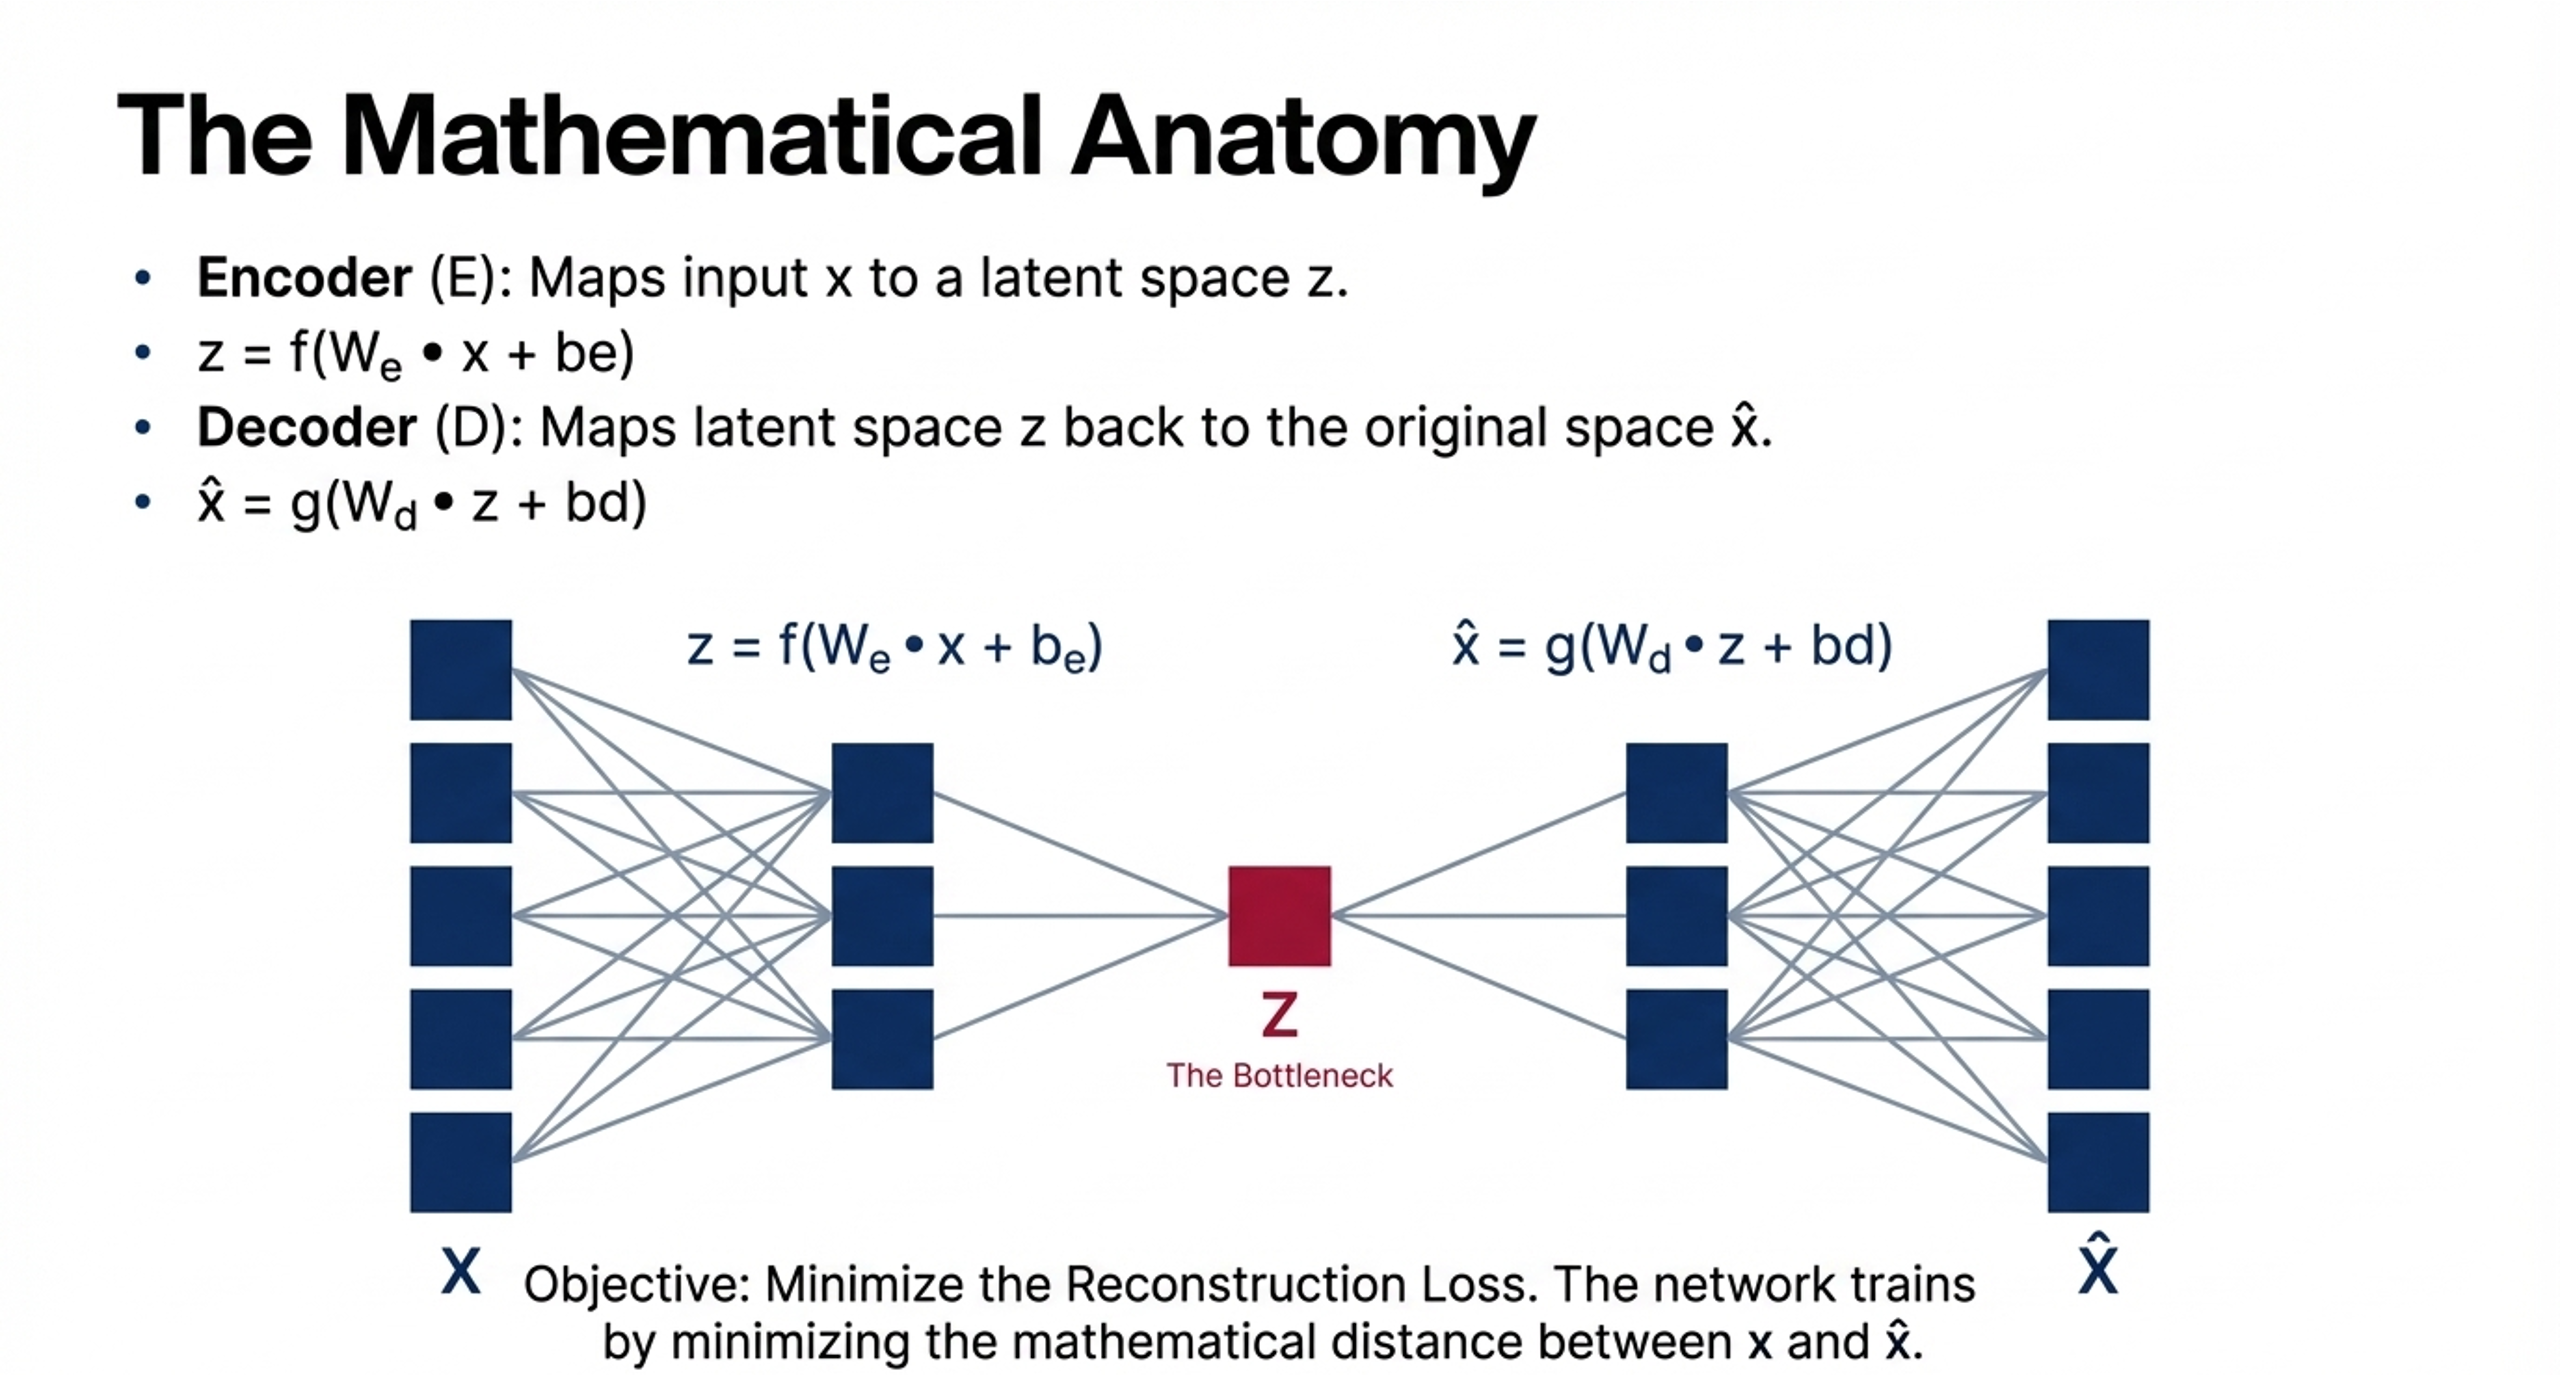

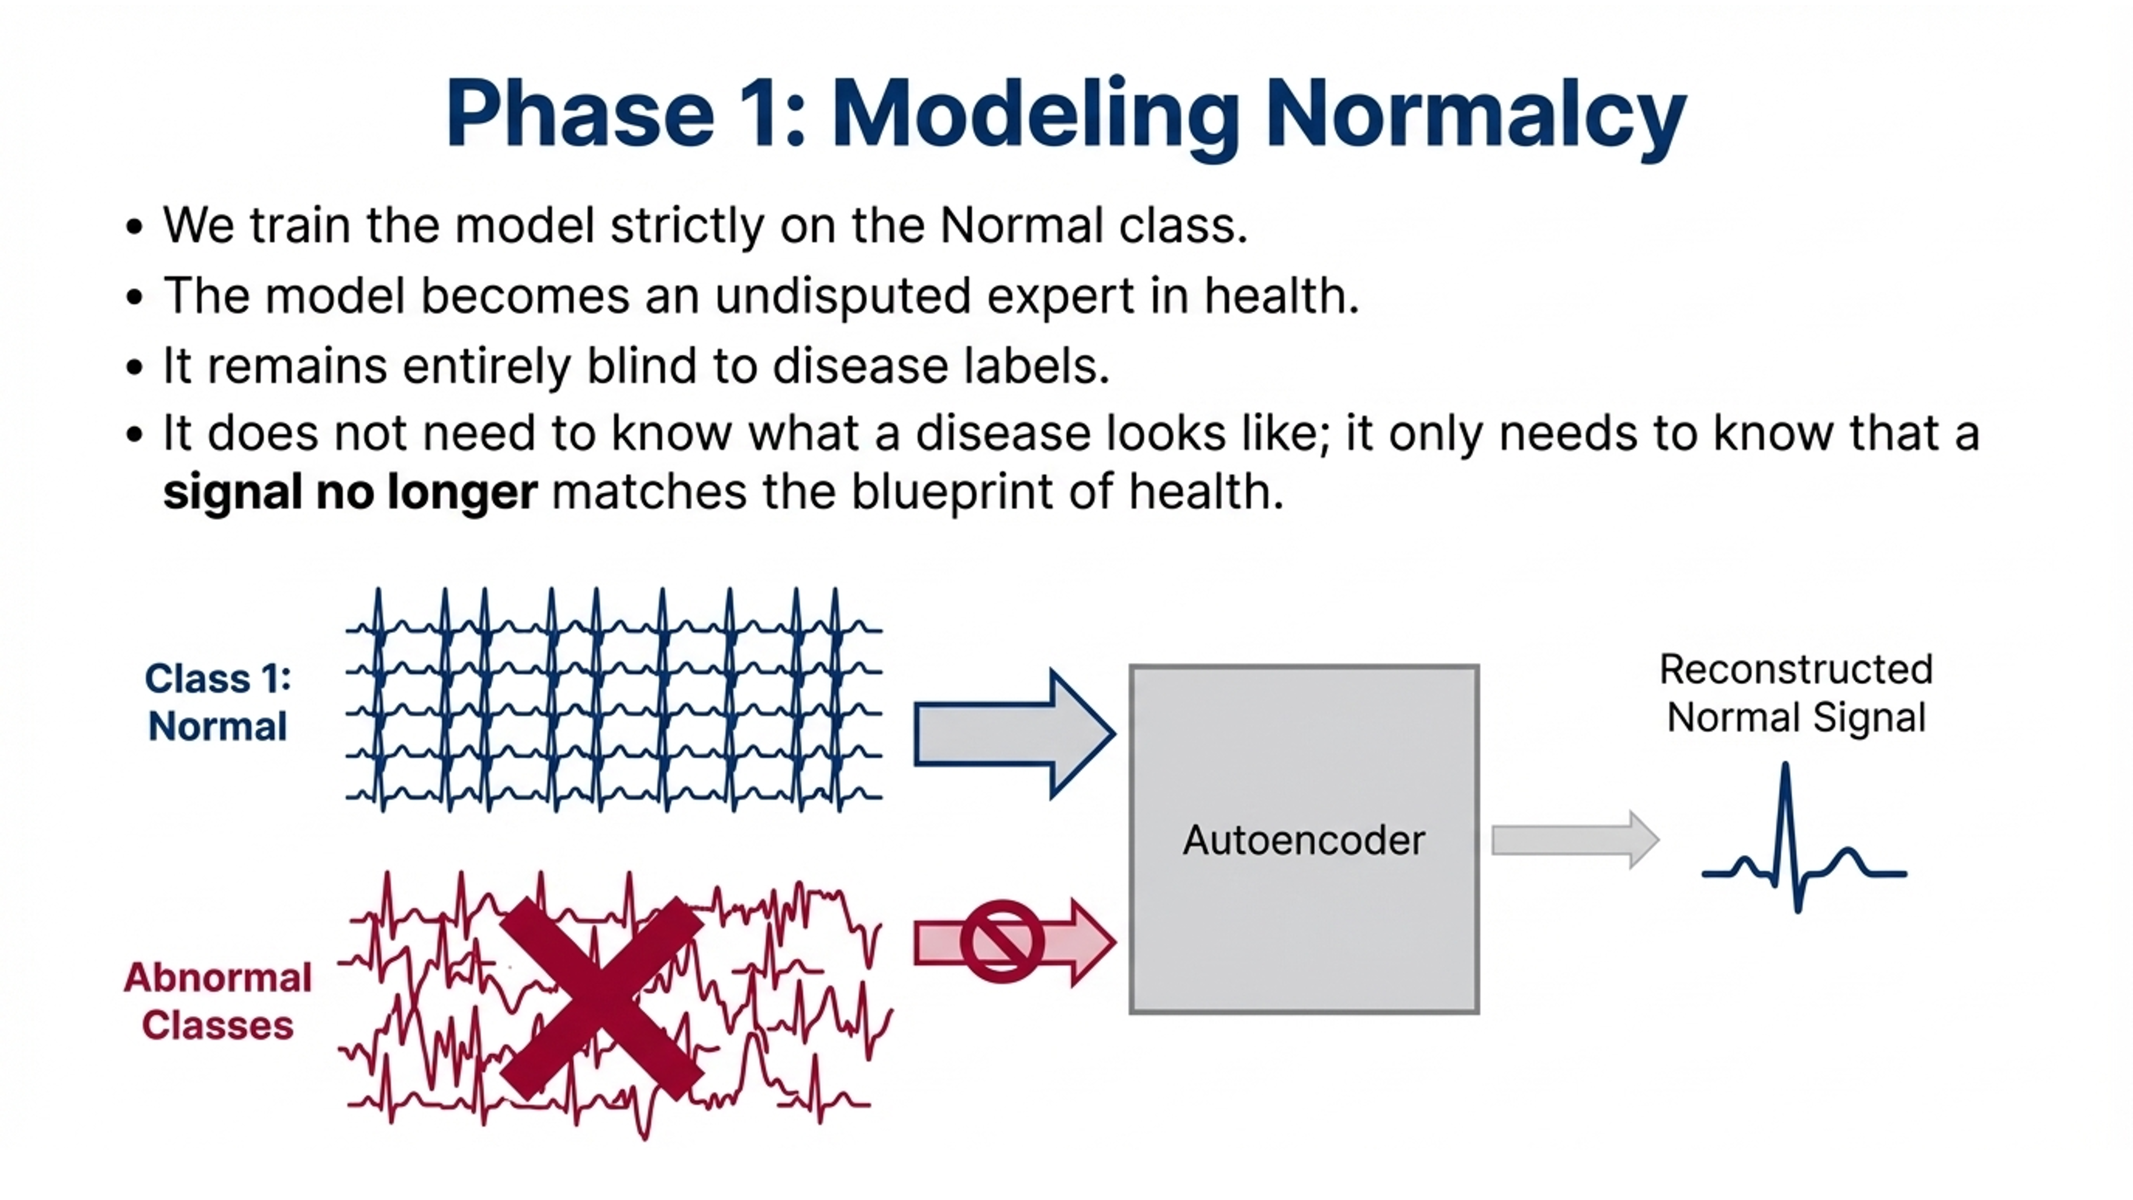

In [ ]:
# Pandas a arreglos numpy
datos_train = df_train.values
datos_test = df_test.values

# Etiquetas
cat_train = datos_train[:,0]
cat_test = datos_test[:,0]

# Subdivisión por categorías
x_train_normal = datos_train[cat_train==0,1:]
x_train_anormal_1 = datos_train[cat_train==1,1:]
x_train_anormal_2 = datos_train[cat_train==2,1:]
x_train_anormal_3 = datos_train[cat_train==3,1:]
x_train_anormal_4 = datos_train[cat_train==4,1:]

x_test_normal = datos_test[cat_test==0,1:]
x_test_anormal_1 = datos_test[cat_test==1,1:]
x_test_anormal_2 = datos_test[cat_test==2,1:]
x_test_anormal_3 = datos_test[cat_test==3,1:]
x_test_anormal_4 = datos_test[cat_test==4,1:]

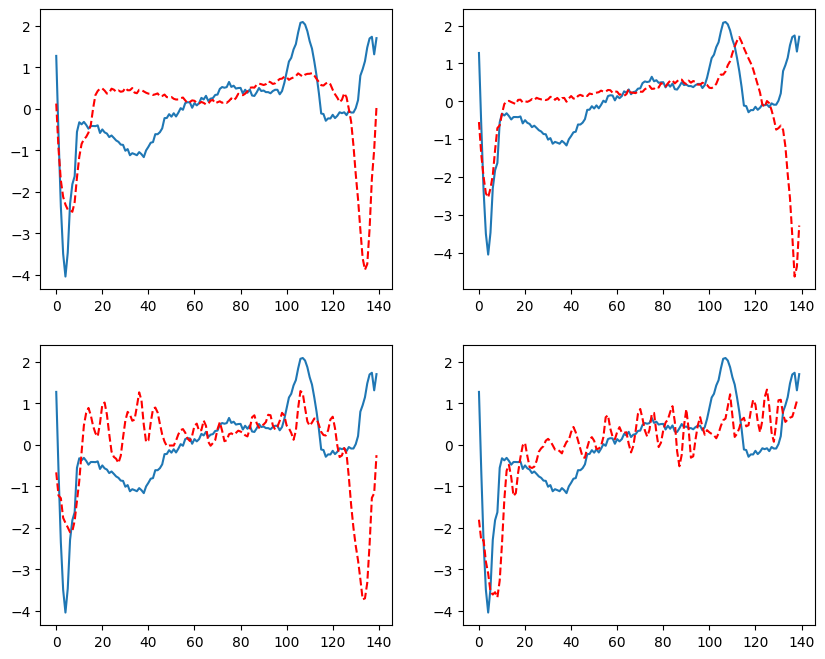

In [ ]:
# Dibujar un dato normal y uno de cada anormal
import matplotlib.pyplot as plt
import numpy as np

ind = 10

plt.figure(figsize=(10,8))
# plt.grid()
plt.subplot(2,2,1)
plt.plot(np.arange(140), x_train_normal[ind])
plt.plot(np.arange(140), x_train_anormal_1[ind], 'r--')
plt.subplot(2,2,2)
plt.plot(np.arange(140), x_train_normal[ind])
plt.plot(np.arange(140), x_train_anormal_2[ind], 'r--')
plt.subplot(2,2,3)
plt.plot(np.arange(140), x_train_normal[ind])
plt.plot(np.arange(140), x_train_anormal_3[ind], 'r--')
plt.subplot(2,2,4)
plt.plot(np.arange(140), x_train_normal[ind])
plt.plot(np.arange(140), x_train_anormal_4[ind], 'r--')
plt.show()

## Preprocesing

In [ ]:
x_train_normal.max()

np.float64(4.9664)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(x_train_normal)

x_train_normal_s = scaler.transform(x_train_normal)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
min_max_scaler = MinMaxScaler()

x_train_normal_s = min_max_scaler.fit_transform(x_train_normal)
print('Mínimo y máximo originales: {:.1f}, {:.1f}'.format(np.min(x_train_normal), np.max(x_train_normal)))
print('Mínimo y máximo normalización: {:.1f}, {:.1f}'.format(np.min(x_train_normal_s), np.max(x_train_normal_s)))


# Train
x_train_anormal_1_s = min_max_scaler.transform(x_train_anormal_1)
x_train_anormal_2_s = min_max_scaler.transform(x_train_anormal_2)
x_train_anormal_3_s = min_max_scaler.transform(x_train_anormal_3)
x_train_anormal_4_s = min_max_scaler.transform(x_train_anormal_4)


# Test
x_test_normal_s = min_max_scaler.transform(x_test_normal)
x_test_anormal_1_s = min_max_scaler.transform(x_test_anormal_1)
x_test_anormal_2_s = min_max_scaler.transform(x_test_anormal_2)
x_test_anormal_3_s = min_max_scaler.transform(x_test_anormal_3)
x_test_anormal_4_s = min_max_scaler.transform(x_test_anormal_4)

Mínimo y máximo originales: -7.1, 5.0
Mínimo y máximo normalización: 0.0, 1.0


In [ ]:
x_test_normal_s

array([[0.38416026, 0.26263468, 0.07038481, ..., 0.69742408, 0.64440266,
        0.4113677 ],
       [0.47303756, 0.34270938, 0.04187375, ..., 0.67639268, 0.77491786,
        0.58590184],
       [0.54839132, 0.49013073, 0.32869557, ..., 0.49607673, 0.55876686,
        0.4799064 ],
       ...,
       [0.25690199, 0.27437629, 0.08850927, ..., 0.64198743, 0.67682628,
        0.64486853],
       [0.69114818, 0.66144615, 0.47212881, ..., 0.70296672, 0.61972737,
        0.38895252],
       [0.52318077, 0.45001197, 0.28098866, ..., 0.46296391, 0.58412178,
        0.55294292]])

In [ ]:
x_train_anormal_1_s.shape[1]

140

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
np.random.seed(23)

dim_entrada = x_train_anormal_1_s.shape[1]    #140 muestras/ejemplo
entrada = Input(shape=(140,))

# Encoder
encoder = Dense(32, activation='relu')(entrada)
encoder = Dense(16, activation='relu')(encoder)
encoder = Dense(8, activation='relu')(encoder)

# Decoder
decoder = Dense(16, activation='relu')(encoder)
decoder = Dense(32, activation='relu')(decoder)
decoder = Dense(140, activation='sigmoid')(decoder)

# Autoencoder = entrada + decoder (que ya contiene el encoder)
autoencoder = Model(inputs=entrada, outputs=decoder)

autoencoder.summary()

Model: "functional_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 140)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 32)             │         4,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 140)            │         4,620 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,484 (40.95 KB)

 Trainable params: 10,484 (40.95 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
autoencoder.predict(x_train_normal_s)

139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[0.5216447 , 0.5408358 , 0.513485  , ..., 0.46835572, 0.4990959 ,
        0.5057264 ],
       [0.51856345, 0.5339085 , 0.51260763, ..., 0.4742839 , 0.4977965 ,
        0.5047881 ],
       [0.51717347, 0.5310828 , 0.51056224, ..., 0.47502875, 0.49854606,
        0.5043202 ],
       ...,
       [0.5165964 , 0.53032506, 0.50971943, ..., 0.47540572, 0.49878904,
        0.50415367],
       [0.5187553 , 0.5342947 , 0.5122866 , ..., 0.4727081 , 0.49791244,
        0.50510967],
       [0.51598173, 0.5289622 , 0.51050615, ..., 0.47676829, 0.49871448,
        0.5044652 ]], dtype=float32)

In [ ]:
autoencoder.compile(optimizer='adam', loss='mae')
historia = autoencoder.fit(x_train_normal_s, x_train_normal_s,
          epochs=200,
          batch_size=512,
          validation_data=(x_test_normal_s, x_test_normal_s),
          shuffle=True)

Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 278ms/step - loss: 0.1277 - val_loss: 0.1224
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1194 - val_loss: 0.1108
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1073 - val_loss: 0.0977
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0945 - val_loss: 0.0861
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0835 - val_loss: 0.0778
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0762 - val_loss: 0.0727
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0714 - val_loss: 0.0695
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0693 - val_loss: 0.0671
Epoch 9/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0664 - val_loss: 0.0656
Epoch 10/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0651 - val_loss: 0.0649
Epoch 11/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0649 - val_loss: 0.0644
Epoch 12/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0646 - val_l

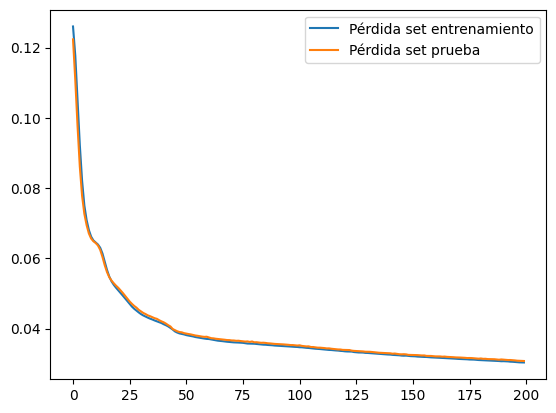

In [ ]:
plt.plot(historia.history["loss"], label="Pérdida set entrenamiento")
plt.plot(historia.history["val_loss"], label="Pérdida set prueba")
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


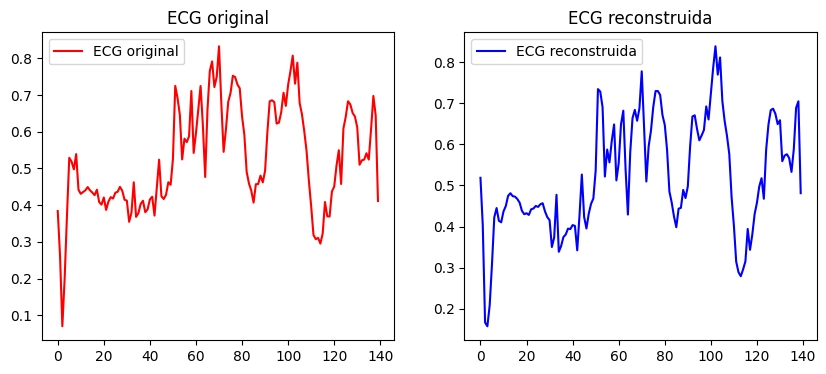

In [ ]:
ecg_original = x_test_normal_s[0]
ecg_reconstruida = autoencoder.predict(ecg_original.reshape(1, -1))[0]

# plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(ecg_original
         , label='ECG original', color='r')
plt.title('ECG original')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(ecg_reconstruida
         , label='ECG reconstruida', color='b')
plt.title('ECG reconstruida')
plt.legend()


# Classification

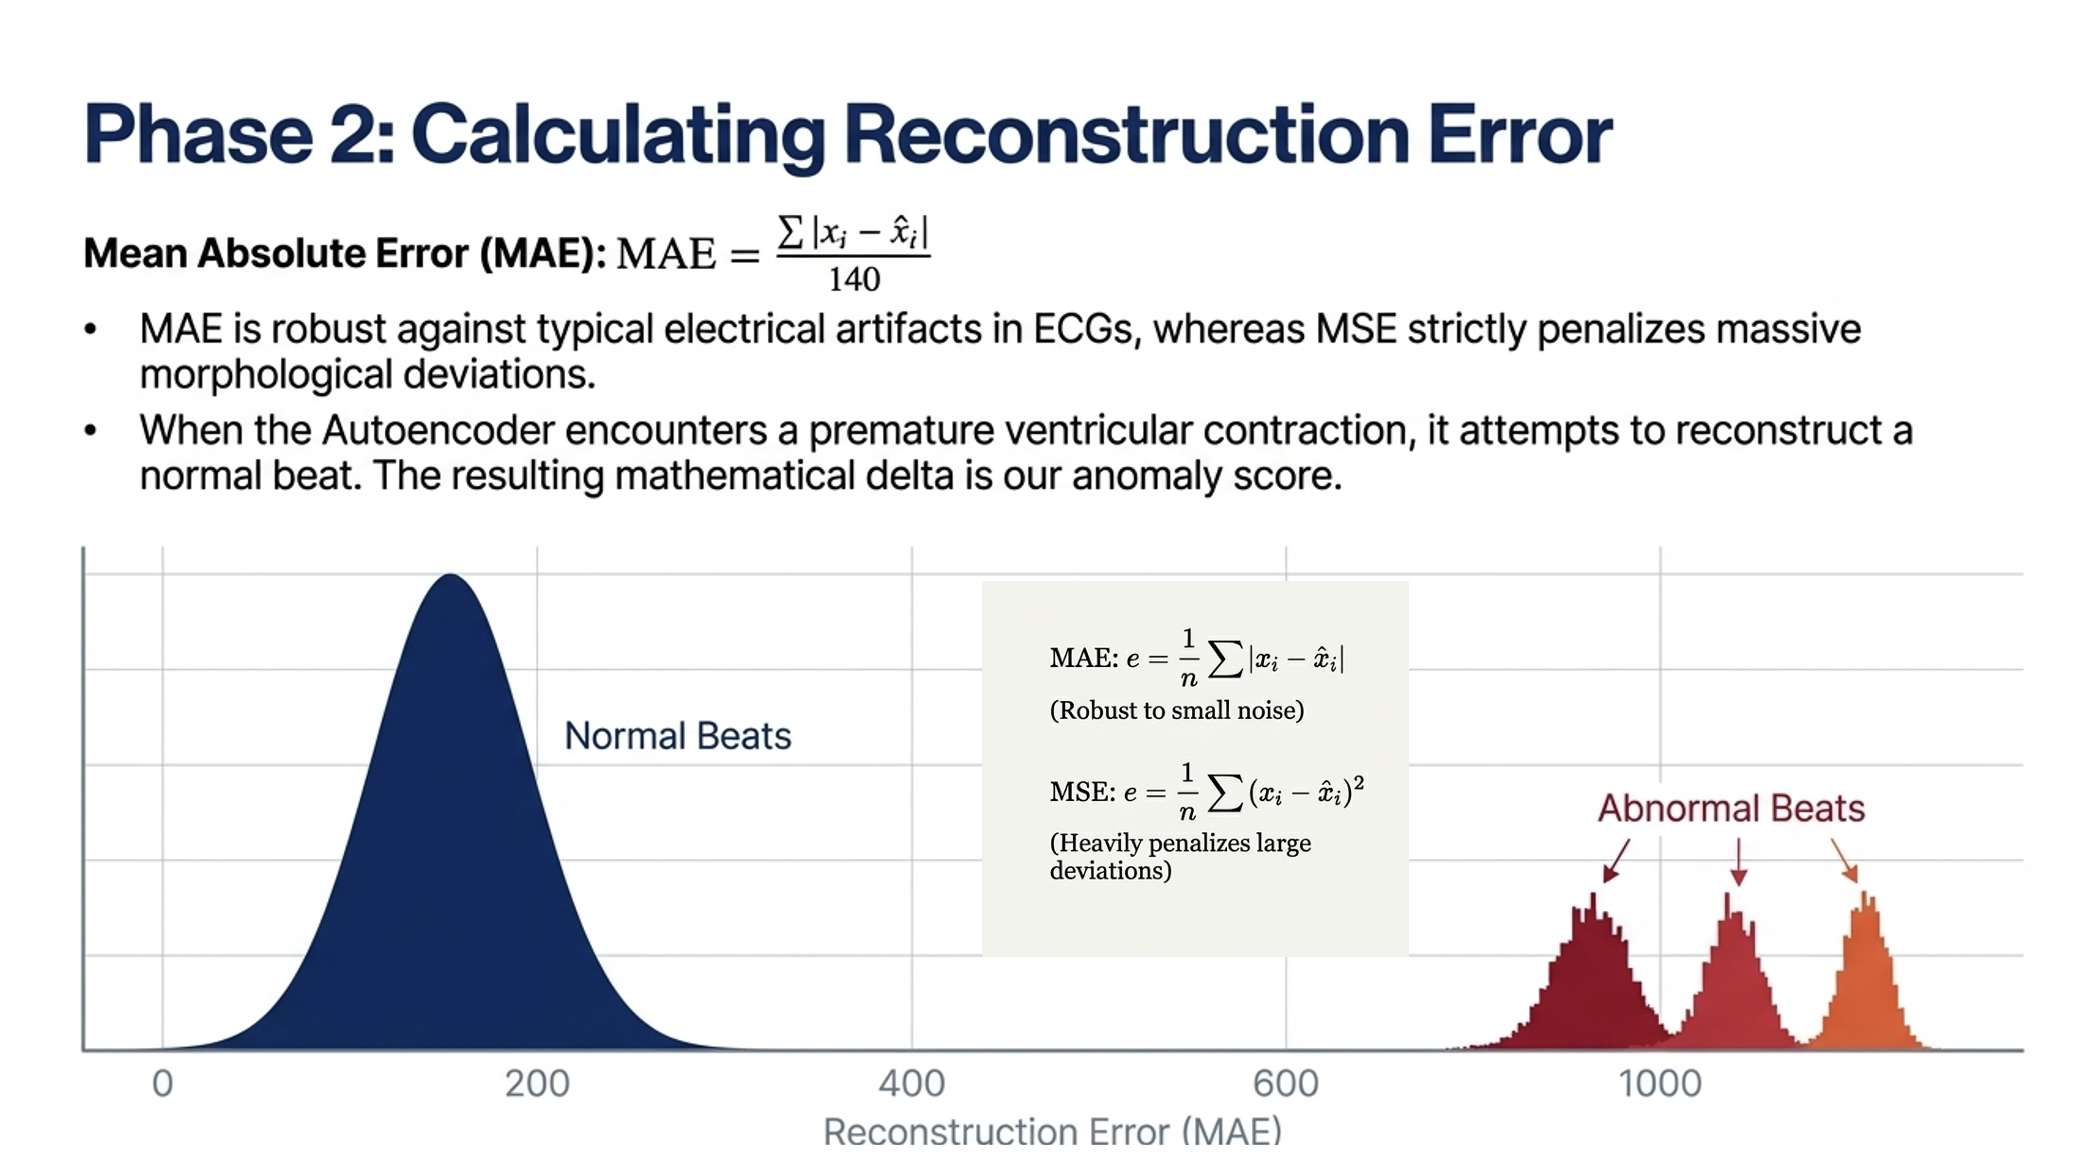

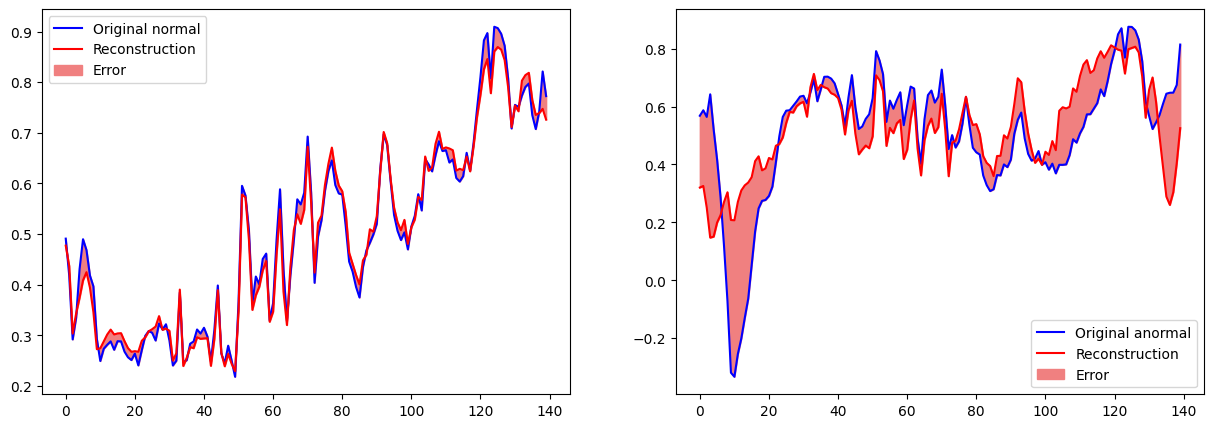

In [ ]:
# ¿Qué tan bien reconstruye un dato "normal" y uno anormal?
rec_normal = autoencoder(x_test_normal_s).numpy()
rec_anormal = autoencoder(x_test_anormal_4_s).numpy()

dato = 5
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(x_test_normal_s[dato],'b')
plt.plot(rec_normal[dato],'r')
plt.fill_between(np.arange(140), rec_normal[dato], x_test_normal_s[dato], color='lightcoral')
plt.legend(labels=["Original normal", "Reconstruction", "Error"])
plt.subplot(1,2,2)
plt.plot(x_test_anormal_4_s[dato],'b')
plt.plot(rec_anormal[dato],'r')
plt.fill_between(np.arange(140), rec_anormal[dato], x_test_anormal_4_s[dato], color='lightcoral')
plt.legend(labels=["Original anormal", "Reconstruction", "Error"])

In [ ]:
import tensorflow as tf

# Calculate MAE for both of them
loss_normal = tf.keras.losses.mae(rec_1, x_test_normal_s)
loss_aberrant = tf.keras.losses.mae(rec_1, x_test_normal_s)

loss_normal, loss_aberrant

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


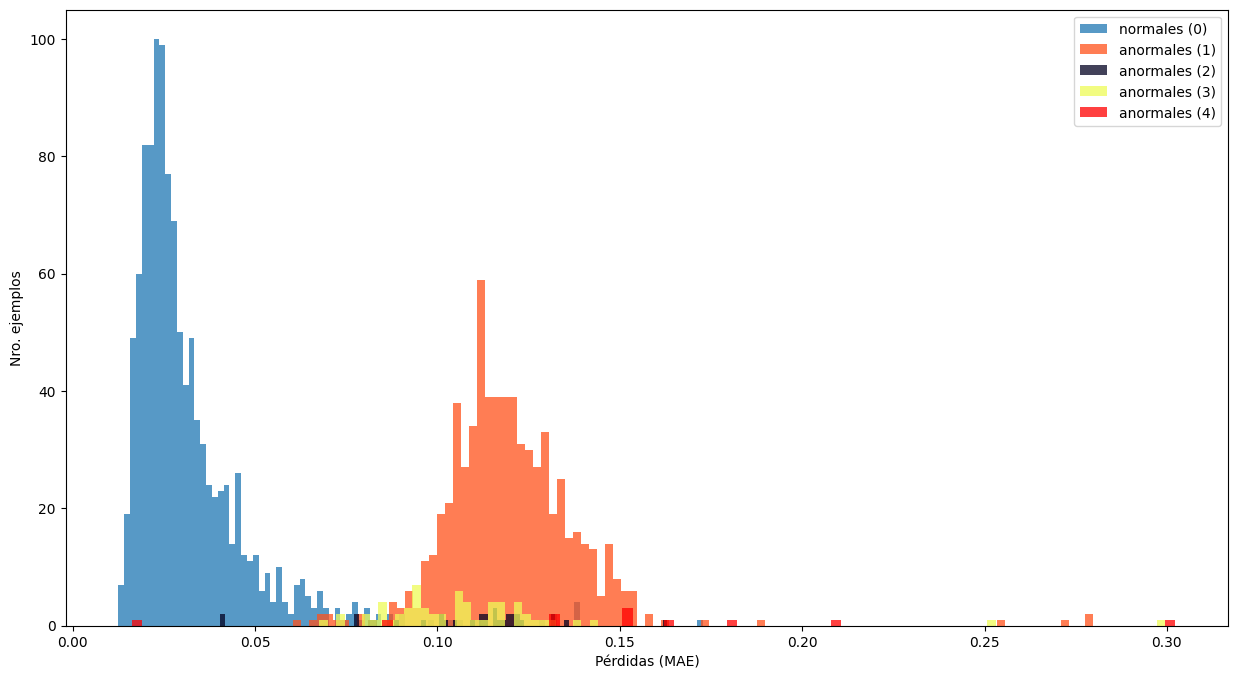

In [ ]:
# Distribuciones de los errores de construcción
# para cada categoría

import tensorflow as tf

rec_1 = autoencoder.predict(x_test_normal_s)
rec_2 = autoencoder.predict(x_test_anormal_1_s)
rec_3 = autoencoder.predict(x_test_anormal_2_s)
rec_4 = autoencoder.predict(x_test_anormal_3_s)
rec_5 = autoencoder.predict(x_test_anormal_4_s)

loss_1 = tf.keras.losses.mae(rec_1, x_test_normal_s)
loss_2 = tf.keras.losses.mae(rec_2, x_test_anormal_1_s)
loss_3 = tf.keras.losses.mae(rec_3, x_test_anormal_2_s)
loss_4 = tf.keras.losses.mae(rec_4, x_test_anormal_3_s)
loss_5 = tf.keras.losses.mae(rec_5, x_test_anormal_4_s)


plt.figure(figsize=(15,8))
plt.hist(loss_1[None,:], bins=100, alpha=0.75, label='normales (0)')
plt.hist(loss_2[None,:], bins=100, alpha=0.75, color='#ff521b', label='anormales (1)')
plt.hist(loss_3[None,:], bins=100, alpha=0.75, color='#020122', label='anormales (2)')
plt.hist(loss_4[None,:], bins=100, alpha=0.75, color='#eefc57', label='anormales (3)')
plt.hist(loss_5[None,:], bins=100, alpha=0.75, color='r', label='anormales (4)')
plt.xlabel('Pérdidas (MAE)')
plt.ylabel('Nro. ejemplos')
plt.legend(loc='upper right')
#plt.vlines(0.08,0,70,'k')



# Thresholds

### 5.1. Sensitividad y especificidad

- Verdaderos positivos (TP): anormales que han sido correctamente clasificados como anormales
- Falsos negativos (FN): anormales que han sido clasificados erróneamente como normales
- Verdaderos negativos (TN): normales que han sido correctamente clasificados como normales
- Falsos positivos (FP): normales que han sido clasificados erróneamente como anormales

La **sensitividad** mide la proporción de anormales que fueron detectados correctamente como anormales. Una sensitividad del 100% detectará a todos los pacientes enfermos:

$sensitividad = \frac{TP}{TP+FN}$

La **especificidad** mide la proporción de normales que fueron detectados correctamente como normales. Una especificidad del 100% detectará a todos los pacientes sanos:

$especificidad = \frac{TN}{TN+FP}$

In [ ]:
umbral = np.mean(loss_1) + np.std(loss_1)
print("Umbral: ", umbral)

In [ ]:
# Calcular predicciones individuales
def predecir(modelo, datos, umbral):
    reconstrucciones = modelo(datos)
    perdida = tf.keras.losses.mae(reconstrucciones, datos)
    return tf.math.less(perdida, umbral)

def calcular_sensitividad(prediccion, titulo):
    TP = np.count_nonzero(~prediccion)
    FN = np.count_nonzero(prediccion)
    sen = 100*(TP/(TP+FN))

    print(titulo + ': {:.1f}%'.format(sen))

def calcular_especificidad(prediccion, titulo):
    TN = np.count_nonzero(prediccion)
    FP = np.count_nonzero(~prediccion)
    esp = 100*(TN/(TN+FP))

    print(titulo + ': {:.1f}%'.format(esp))
    return esp

In [ ]:
# Predicciones
pred_1 = predecir(autoencoder, x_test_normal_s, umbral)
pred_2 = predecir(autoencoder, x_test_anormal_1_s, umbral)
pred_3 = predecir(autoencoder, x_test_anormal_2_s, umbral)
pred_4 = predecir(autoencoder, x_test_anormal_3_s, umbral)
pred_5 = predecir(autoencoder, x_test_anormal_4_s, umbral)

# Pred1: especificidad
esp_1 = calcular_especificidad(pred_1,'Especificidad (cat. 1, normales)')

# Pred 2 a 5: sensitividad
sen_2 = calcular_sensitividad(pred_2,'Sensitividad (cat. 2, anormales)')
sen_3 = calcular_sensitividad(pred_3,'Sensitividad (cat. 3, anormales)')
sen_4 = calcular_sensitividad(pred_4,'Sensitividad (cat. 4, anormales)')
sen_5 = calcular_sensitividad(pred_3,'Sensitividad (cat. 5, anormales)')

Especificidad (cat. 1, normales): 89.5%
Sensitividad (cat. 2, anormales): 100.0%
Sensitividad (cat. 3, anormales): 93.9%
Sensitividad (cat. 4, anormales): 100.0%
Sensitividad (cat. 5, anormales): 93.9%
